In [1]:
import numpy as np
import pandas as pd
from anndata import AnnData
import scanpy as sc
import multiprocessing as mp
from tqdm import tqdm

# load package

In [2]:
import os
import sys
sys.path.insert(1, '/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
import unig as ug
ug.__version__

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.1'

In [3]:
workdir = '/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/'
ug.settings.set_workdir(workdir)

Saving results in: /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/


# Data preprocessing

In [4]:
st_RNA_adata = sc.read_h5ad('/home/nas3/biod/yangchenghui/proj2/human_GBM_data/GBM_adata_rna.h5ad')
st_ATAC_adata = sc.read_h5ad('/home/nas3/biod/yangchenghui/proj2/human_GBM_data/GBM_adata_atac.h5ad')

st_RNA_adata.obs['cell_type'] = st_RNA_adata.obs['COMBO_cluster']
st_ATAC_adata.obs['cell_type'] = st_ATAC_adata.obs['COMBO_cluster']

st_RNA_adata, st_ATAC_adata

(AnnData object with n_obs × n_vars = 2768 × 36601
     obs: 'RNA_cluster', 'COMBO_cluster', 'cell_type'
     var: 'feature_type'
     uns: 'COMBO_cluster_colors', 'RNA_cluster_colors'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 2697 × 48093
     obs: 'ATAC_cluster', 'COMBO_cluster', 'cell_type'
     var: 'chr', 'start', 'end', 'qValue'
     uns: 'ATAC_cluster_colors', 'COMBO_cluster_colors'
     obsm: 'spatial')

RNA processing

In [5]:
st_RNA_adata = ug.pp.preprocess_rna(st_RNA_adata)
st_RNA_adata

AnnData object with n_obs × n_vars = 2768 × 24587
    obs: 'RNA_cluster', 'COMBO_cluster', 'cell_type'
    var: 'feature_type', 'n_cells', 'moran_I', 'spatial_qval', 'spatially_variable', 'spatially_variable_rank', 'variable'
    uns: 'COMBO_cluster_colors', 'RNA_cluster_colors', 'log1p', 'spatial_neighbors', 'moranI', 'svg_top_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

ATAC processing

In [6]:
st_ATAC_adata = ug.pp.preprocess_atac(st_ATAC_adata)
peaks_all = list(st_ATAC_adata.var_names)
st_ATAC_adata

AnnData object with n_obs × n_vars = 2697 × 40116
    obs: 'ATAC_cluster', 'COMBO_cluster', 'cell_type'
    var: 'chr', 'start', 'end', 'qValue', 'n_cells'
    uns: 'ATAC_cluster_colors', 'COMBO_cluster_colors'
    obsm: 'spatial'

For each variable gene, select ATAC peaks that fall within the gene body or in its upstream/downstream regions 

In [7]:
gene_info = pd.read_csv('/home/nas3/biod/yangchenghui/nas2_ych/FGOT-master/data/PBMC_data/hg38.promoter.regions.txt', sep = '\t')
gene_info.head()

,chr,starts,ends,genes
1,chr1,12623,12624.0,DDX11L1
2,chr1,30120,30121.0,WASH7P
3,chr1,18186,18187.0,MIR6859.1
4,chr1,18186,18187.0,MIR6859.2
5,chr1,18186,18187.0,MIR6859.3


In [8]:
genes_selected = st_RNA_adata.var_names[st_RNA_adata.var['spatially_variable']].tolist()
filtered_genes, filtered_peaks, gene_peaks = ug.pp.select_gene_peaks_by_genes_location(gene_info, genes_selected, peaks_all)

Preprocessing gene_info:


72337it [00:00, 100067.44it/s]


Search the genes-peaks correspondence based on gene_info and scope:


41399it [00:35, 1166.99it/s]


Search the filtered peaks:


100%|██████████| 1732/1732 [00:00<00:00, 359505.84it/s]

There are 1732 genes that can be identified from the TSS information.
There are 22692 peaks near the upstream and downstream of the above genes.


In [9]:
stRNA_adata_fltr = st_RNA_adata[:,filtered_genes]
stATAC_adata_fltr = st_ATAC_adata[:,filtered_peaks]
stRNA_adata_fltr,stATAC_adata_fltr

stRNA_adata_fltr.write(workdir + "/GBM_stRNA_adata_fltr.h5ad")
stATAC_adata_fltr.write(workdir + "/GBM_stATAC_adata_fltr.h5ad")

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


gene-peak relation

In [10]:
from scipy import sparse
gene_to_idx = {gene: i for i, gene in enumerate(filtered_genes)}
peak_to_idx = {peak: i for i, peak in enumerate(filtered_peaks)}
rows = []
cols = []

filtered_peaks_set = set(filtered_peaks)
for gene in tqdm(filtered_genes):
    if gene in gene_peaks:
        current_peaks = gene_peaks[gene]
        valid_peaks = [p for p in current_peaks if p in peak_to_idx]
        if valid_peaks:
            g_idx = gene_to_idx[gene]
            p_idxs = [peak_to_idx[p] for p in valid_peaks]
            rows.extend([g_idx] * len(p_idxs))
            cols.extend(p_idxs)
data = np.ones(len(rows), dtype=int)
sparse_mat = sparse.coo_matrix((data, (rows, cols)), 
                               shape=(len(filtered_genes), len(filtered_peaks))).tocsr()
adata_GP = sc.AnnData(X=sparse_mat)
adata_GP.obs_names = filtered_genes
adata_GP.var_names = filtered_peaks
adata_GP.write(workdir+"adata_GenePeak_final.h5ad")
adata_GP

100%|██████████| 1732/1732 [00:00<00:00, 91572.46it/s]


AnnData object with n_obs × n_vars = 1732 × 22692

gene expression discretization

/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()


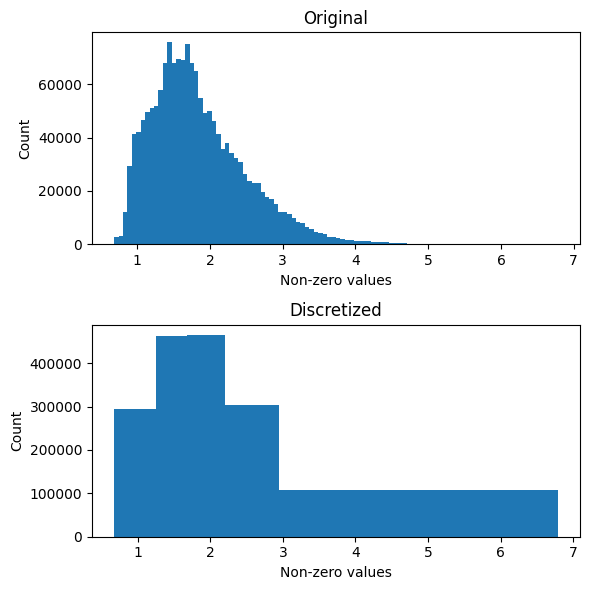

In [11]:
ug.tl.discretize(stRNA_adata_fltr,n_bins=5)
ug.pl.discretize(stRNA_adata_fltr,kde=False)
stRNA_adata_fltr.write(workdir+"/stRNA_adata_fltr_final.h5ad")

peak accessibility binarization

In [12]:
ug.pp.binarize(stATAC_adata_fltr)
stATAC_adata_fltr.write(workdir+"/stATAC_adata_fltr_final.h5ad")

peak-motif relation

In [13]:
# Pure Python peak x motif scanning with defaults matching the motifmatchr workflow.
# Register the FASTA once per Python process; later scans only need peaks and genome.
ug.pp.register_genome(
    "hg38",
    ("/home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/hg38/hg38.fa"),
)
peak_motif_matrix = ug.pp.peak_motif_matrix(
    stATAC_adata_fltr.var_names,
    genome="hg38",
    n_jobs=min(8, mp.cpu_count()),
)

adata_PM = AnnData(peak_motif_matrix)
ug.pp.binarize(adata_PM)

adata_PM.write(workdir+"adata_PeakMotif_final.h5ad")
adata_PM

AnnData object with n_obs × n_vars = 22692 × 633

spatial spot-spot relation

In [14]:
adata_C_spatial = ug.tl.SpaNeighbor(stRNA_adata_fltr, k = 10)
adata_C_spatial.write(workdir+"spatial_InnerCell_final.h5ad")
adata_C_spatial

AnnData object with n_obs × n_vars = 2768 × 2768

# Generate graph

In [19]:
GBM_stRNA_adata_fltr = sc.read_h5ad(workdir+"/stRNA_adata_fltr_final.h5ad")
GBM_stATAC_adata_fltr = sc.read_h5ad(workdir+"/stATAC_adata_fltr_final.h5ad")

adata_PM= sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_GP= sc.read_h5ad(workdir+"/adata_GenePeak_final.h5ad")
adata_C_spatial= sc.read_h5ad(workdir+"/spatial_InnerCell_final.h5ad")

In [20]:
ug.gen_graph(list_CP=[GBM_stATAC_adata_fltr],
             list_CG=[GBM_stRNA_adata_fltr],
             list_PM=[adata_PM],
             list_CC_Spatial=[adata_C_spatial],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_0')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C, destination: P
#edges: 1390023
`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation1: source: P, destination: M
#edges: 934363


relation2: source: C, destination: G
#edges: 295465
relation3: source: C, destination: G
#edges: 462649
relation4: source: C, destination: G
#edges: 465283
relation5: source: C, destination: G
#edges: 302823
relation6: source: C, destination: G
#edges: 108330
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instead.
relation7 (Spatial): source: C, destination: C
#edges: 30818
`unig` does not exist in anndata 0 in `list_GP`.`.X` is being used instead.
relation8: source: G, destination: P
#edges: 40674
Total number of edges: 4030428
Writing graph file "pbg_graph.txt" to "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/pbg/graph1_0" ...
Finished.


# Training

In [21]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 0,
            "alpha_ot_gp": 2000,
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 8.791908E-03
Training mode: standard
Converting input data...
[2026-08-30 10:01:40.614944] Using the 9 relation types given in the config
[2026-08-30 10:01:40.615886] Searching for the entities in the edge files...
[2026-08-30 10:01:45.030603] Entity type C:
[2026-08-30 10:01:45.031914] - Found 2768 entities
[2026-08-30 10:01:45.032246] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 10:01:45.033308] - Left with 2768 entities
[2026-08-30 10:01:45.033642] - Shuffling them...
[2026-08-30 10:01:45.035081] Entity type G:
[2026-08-30 10:01:45.035472] - Found 1732 entities
[2026-08-30 10:01:45.035747] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 10:01:45.036810] - Left with 1732 entities
[2026-08-30 10:01:45.037098] - Shuffling them...
[2026-08-30 10:01:45.037938] Entity type P:
[2026-08-30 10:01:45.038251] - Found 22692 entities
[

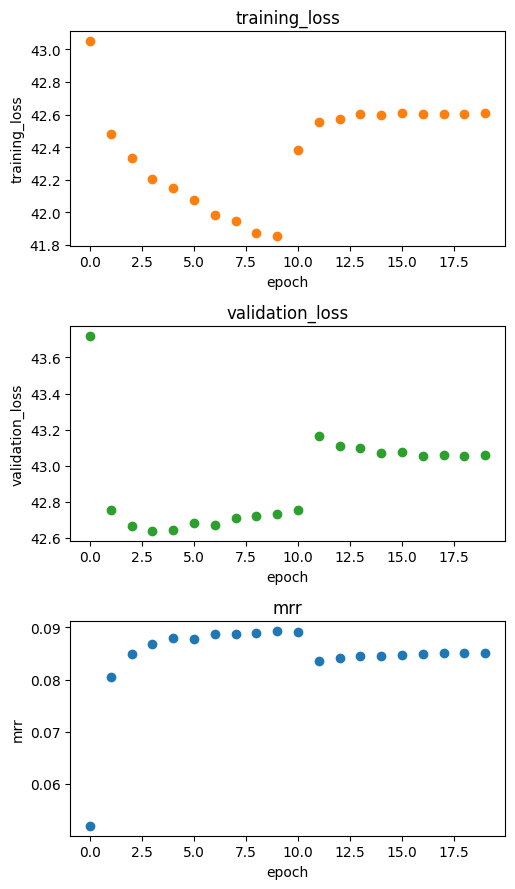

In [22]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

# Post-training analysis

In [23]:
dict_adata = ug.tl.read_embedding()
dict_adata

{'C': AnnData object with n_obs × n_vars = 2768 × 50,
 'P': AnnData object with n_obs × n_vars = 22692 × 50,
 'M': AnnData object with n_obs × n_vars = 633 × 50,
 'G': AnnData object with n_obs × n_vars = 1732 × 50}

In [ ]:
adata_C = dict_adata['C']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "Cell"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C.obs['celltype'] = GBM_stRNA_adata_fltr[adata_C.obs_names,:].obs['cell_type'].copy()
adata_C.obsm['spatial'] = GBM_stRNA_adata_fltr[adata_C.obs_names,:].obsm['spatial'].copy()

visualize embeddings of cells

fitting ...
  |======================================================================| 100%


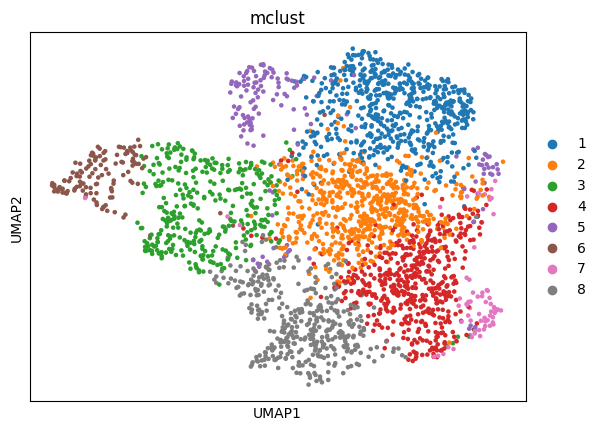

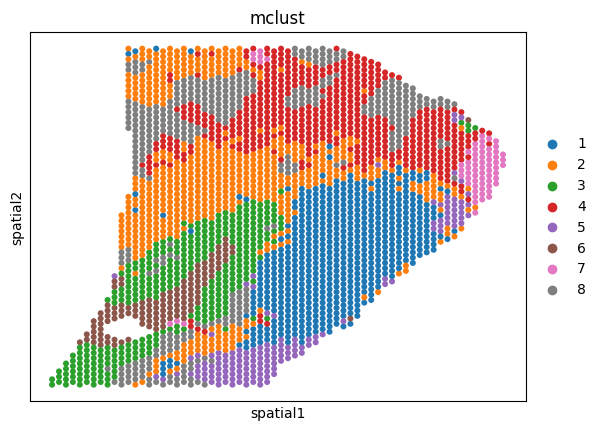

In [43]:
sc.pp.neighbors(adata_C)
sc.tl.umap(adata_C)
ug.tl.mclust_R(adata_C,8,modelNames='EEI')
sc.pl.umap(adata_C, color=["mclust"])
sc.pl.embedding(adata_C, basis='spatial', color=["mclust"], size=75)

In [26]:
# save
import pickle
adata_dict = {
    'C': adata_C,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'HumanGBM_UniG_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'HumanGBM_UniG_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/HumanGBM_UniG_adata_dict.pkl


# Identification of TF regulatory activity 

Shuffle peak-motif links in UniG graph, keep rest unchanged, to mimic chromVAR's background removal.

In [48]:
GBM_stRNA_adata_fltr = sc.read_h5ad(workdir+"/stRNA_adata_fltr_final.h5ad")
GBM_stATAC_adata_fltr = sc.read_h5ad(workdir+"/stATAC_adata_fltr_final.h5ad")

adata_GP = sc.read_h5ad(workdir+"/adata_GenePeak_final.h5ad")
adata_C_spatial = sc.read_h5ad(workdir+"/spatial_InnerCell_final.h5ad")

In [49]:
adata_PM = sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_PM_background = ug.grn.shuffle_peak_motif(GBM_stATAC_adata_fltr, adata_PM, genome="hg38")
adata_PM_background

Step 1: Computing peak accessibility.
Step 2: Computing GC content.
Loading genome from /home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/hg38/hg38.fa.


Calculating GC: 100%|██████████| 22692/22692 [00:02<00:00, 7710.30it/s] 


Step 3: Finding background peaks.
Background indices shape: (22692, 50)
Step 4: Loading peak-motif matrix.
Step 5: Generating background peak-motif matrix.


Processing motifs: 100%|██████████| 633/633 [00:04<00:00, 148.87it/s]


Finished background matrix: (22692, 633)


AnnData object with n_obs × n_vars = 22692 × 633

generate background graph and training

In [31]:
ug.gen_graph(list_CP=[GBM_stATAC_adata_fltr],
             list_CG=[GBM_stRNA_adata_fltr],
             list_PM=[adata_PM_background],
             list_CC_Spatial=[adata_C_spatial],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_bg')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C, destination: P
#edges: 1390023
`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation1: source: P, destination: M
#edges: 934363
relation2: source: C, destination: G
#edges: 295465
relation3: source: C, destination: G
#edges: 462649
relation4: source: C, destination: G
#edges: 465283
relation5: source: C, destination: G
#edges: 302823
relation6: source: C, destination: G
#edges: 108330
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instead.
relation7 (Spatial): source: C, destination: C
#edges: 30818
`unig` does not exist in anndata 0 in `list_GP`.`.X` is being used instead.
relation8: source: G, destination: P
#edges: 40674
Total number of edges: 4030428
Writing graph file "pbg_graph.txt" to "/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/pbg/graph_bg" ...
Finished.


In [32]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 0,
            "alpha_ot_gp": 2000,
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 8.791908E-03
Training mode: joint (RNA-OT=10000, ATAC-OT=20000, GP-OT=2000)
Converting input data...
  Reading edge values from 4th column for downstream losses...
[2026-08-30 10:19:53.649477] Using the 9 relation types given in the config
[2026-08-30 10:19:53.650193] Searching for the entities in the edge files...


[2026-08-30 10:19:58.049442] Entity type C:
[2026-08-30 10:19:58.051079] - Found 2768 entities
[2026-08-30 10:19:58.051524] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 10:19:58.052525] - Left with 2768 entities
[2026-08-30 10:19:58.052934] - Shuffling them...
[2026-08-30 10:19:58.054320] Entity type G:
[2026-08-30 10:19:58.054751] - Found 1732 entities
[2026-08-30 10:19:58.055063] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 10:19:58.055718] - Left with 1732 entities
[2026-08-30 10:19:58.056057] - Shuffling them...
[2026-08-30 10:19:58.056933] Entity type P:
[2026-08-30 10:19:58.057284] - Found 22692 entities
[2026-08-30 10:19:58.057579] - Removing the ones with fewer than 1 occurrences...
[2026-08-30 10:19:58.061753] - Left with 22692 entities
[2026-08-30 10:19:58.062292] - Shuffling them...
[2026-08-30 10:19:58.074466] Entity type M:
[2026-08-30 10:19:58.075305] - Found 633 entities
[2026-08-30 10:19:58.075683] - Removing the ones with fewer t

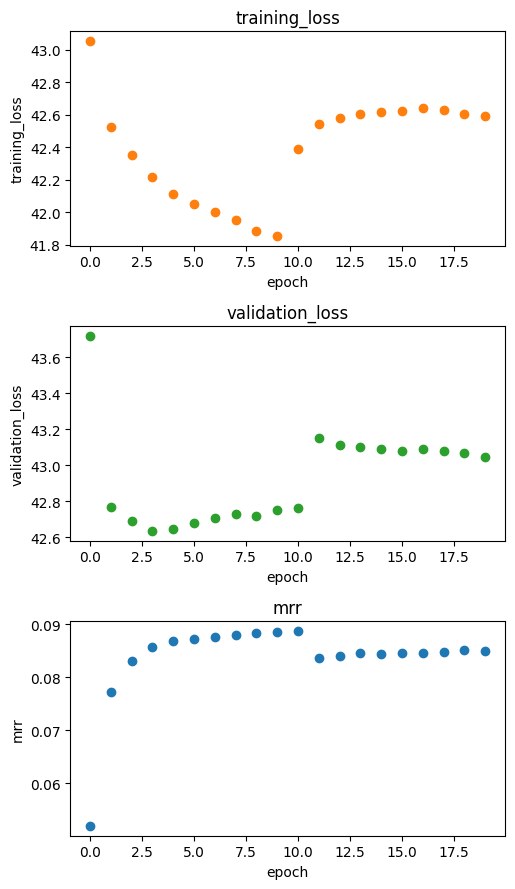

In [33]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

In [35]:
dict_adata = ug.tl.read_embedding()
adata_C = dict_adata['C']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "Cell"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C.obs['celltype'] = GBM_stRNA_adata_fltr[adata_C.obs_names,:].obs['cell_type'].copy()
adata_C.obsm['spatial'] = GBM_stRNA_adata_fltr[adata_C.obs_names,:].obsm['spatial'].copy()

In [36]:
# save
import pickle
adata_dict = {
    'C': adata_C,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'HumanGBM_UniG_bg_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'HumanGBM_UniG_bg_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/HumanGBM_UniG_bg_adata_dict.pkl


calculation of TF regulatory activity

In [41]:
# before correction
import pickle
with open(workdir+'HumanGBM_UniG_adata_dict.pkl', 'rb') as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata['C']
adata_M = dict_adata['M']  # embeddings for motifs

# background
with open(workdir+'HumanGBM_UniG_bg_adata_dict.pkl', 'rb') as f:
    dict_adata = pickle.load(f)
adata_C_bg = dict_adata['C']
adata_M_bg = dict_adata['M']  # embeddings for motifs

# correct
adata_TF_expression = ug.grn.correct_TF_activity(adata_C,adata_M, adata_C_bg, adata_M_bg)
adata_TF_expression

AnnData object with n_obs × n_vars = 2768 × 633
    obs: 'entity_anno', 'celltype', 'leiden', 'mclust'
    var: 'entity_anno'
    obsm: 'spatial', 'X_umap'

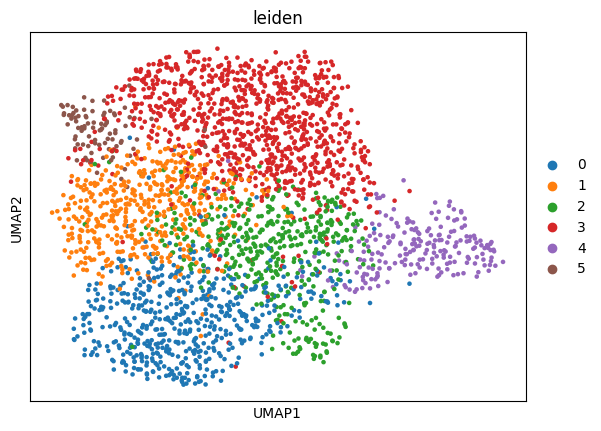

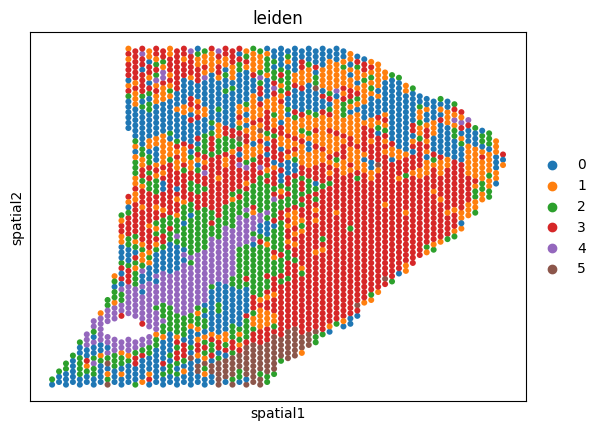

In [42]:
adata = adata_TF_expression.copy()

sc.pp.scale(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution= 0.5, flavor="igraph")
sc.pl.umap(adata, color=["leiden"])
sc.pl.embedding(adata, basis='spatial', color=["leiden"], size=75)
adata.write(workdir+"HumanGBM_TF_regulatory_activity_adata.h5ad")

# Construction of cell-type specific GRNs 

In [4]:
adata_PM = sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_TF_expression = sc.read_h5ad(workdir+"HumanGBM_TF_regulatory_activity_adata.h5ad")

import pickle
with open(workdir+'HumanGBM_UniG_adata_dict.pkl', 'rb') as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata['C']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs
adata_C,adata_G,adata_P,adata_M

(AnnData object with n_obs × n_vars = 2768 × 50
     obs: 'entity_anno', 'celltype', 'leiden', 'mclust'
     uns: 'neighbors', 'umap', 'leiden', 'leiden_colors', 'mclust_colors', 'celltype_colors'
     obsm: 'spatial', 'X_umap'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 1732 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 22692 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 633 × 50
     obs: 'entity_anno')

cis-regulatory scores were calculated from FGOT.

In [5]:
# result from FGOT
gene_CRE_df = pd.read_csv('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_trait/FGOT_result/GBM_regulatory_cluster.csv')
gene_CRE_df

,gene,peak,score,celltype
0,A2M,chr12:8914131-8914631,4.215556e-05,1
1,A2M,chr12:8949774-8950274,2.690481e-06,1
2,A2M,chr12:8914131-8914631,1.741287e-05,2
3,A2M,chr12:8949774-8950274,9.925163e-06,2
4,A2M,chr12:8914131-8914631,2.275706e-06,3
...,...,...,...,...
325387,ZYX,chr7:143381011-143381511,7.325016e-06,8
325388,ZYX,chr7:143287268-143287768,6.908729e-07,8
325389,ZYX,chr7:143375273-143375773,1.454106e-05,8
325390,ZYX,chr7:143362009-143362509,8.193404e-07,8


calculation cell type-specific GRNs

In [6]:
tf_gene_network = ug.grn.trans_GRN(adata_C, adata_G, adata_P, adata_M, adata_TF_expression, gene_CRE_df, adata_PM,
                 emb_cluster_key='mclust',
                 output_dir = workdir)
tf_gene_network

Starting GRN Inference Pipeline...
Filtering cell types...
Keeping cell types (8): ['2', '1', '4', '8', '3', '5', '6', '7']
Reconstructing expression matrices from embeddings...
Filtering CREs based on cell-type specificity...
Performing Gene-level Min-Max Normalization...
Filtering by gene group (Top 5%)...
Normalized Score limits: Min=0.05, Max Cap=0.5
CellType 1: Selected 108 validated peaks
CellType 2: Selected 10 validated peaks
CellType 3: Selected 179 validated peaks
CellType 4: Selected 44 validated peaks
CellType 5: Selected 1647 validated peaks
CellType 6: Selected 2587 validated peaks
CellType 7: Selected 8474 validated peaks
CellType 8: Selected 576 validated peaks
Calculating cell-type specific average expressions...
Calculating TF binding strength on peaks...
Building TF-Gene Regulatory Network...
Building Peak-TF Index...


Processing Cell Types: 100%|██████████| 8/8 [00:08<00:00,  1.07s/it]


Saving results to /home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/UniG_result/...
GRN Inference Completed.


,TF,gene,regulatory_score,celltype
0,M_ALX3,RPL38,0.117792,1
132025,M_ALX3,RAB30,0.054154,7
132026,M_ALX3,RAB5B,0.098995,7
132027,M_ALX3,RABL6,0.263346,7
132028,M_ALX3,RAC1,0.094078,7
...,...,...,...,...
437000,M_ZSCAN4,NAB2,0.078265,7
436999,M_ZSCAN4,NAA38,0.031151,7
436998,M_ZSCAN4,N4BP3,0.255735,7
437008,M_ZSCAN4,NDUFA11,0.026550,7
